In [1]:
import numpy as np
import pandas as pd 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 
from sklearn.metrics import auc, roc_auc_score, precision_recall_curve, precision_score, recall_score, accuracy_score, f1_score, fbeta_score



In [2]:
df = pd.read_csv('tmp.csv')
print(df.columns)
print(df.describe())
print(df.value_counts(['d', 'click'], normalize=True))

Index(['a', 'b', 'c', 'd', 'click'], dtype='object')
                   a              b              c
count  100000.000000  100000.000000  100000.000000
mean       -0.002978      -0.001912       0.003935
std         0.999424       0.998629       0.999939
min        -4.281627      -4.206775      -4.427009
25%        -0.677736      -0.676992      -0.668556
50%        -0.002269       0.000097       0.004625
75%         0.668522       0.670387       0.677828
max         4.154608       4.377391       4.441572
d  click
z  False    0.32631
y  False    0.31922
x  False    0.31041
   True     0.02451
y  True     0.01399
z  True     0.00556
dtype: float64


In [3]:
# Analyze the data distribution and imbalance
print("\nData Distribution Analysis:")
print("---------------------------")

# Class distribution
click_dist = df['click'].value_counts(normalize=True) * 100
print("\nClass Distribution:")
print(f"False (No Click): {click_dist[False]:.2f}%")
print(f"True (Click): {click_dist[True]:.2f}%")

# Feature distribution by category
print("\nFeature Distribution by Category (d):")
category_dist = df['d'].value_counts()
print(category_dist)

# Basic statistics for numerical features
print("\nNumerical Features Statistics:")
numerical_cols = ['a', 'b', 'c']
print(df[numerical_cols].describe())

# Correlation analysis
print("\nFeature Correlations:")
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Key insights summary
print("\nKey Insights:")
print("1. The dataset is highly imbalanced with majority of non-clicks")
print("2. Features a, b, c show varying distributions and ranges")
print("3. The categorical feature 'd' has three distinct values: x, y, z")
print("4. The target variable 'click' is binary (True/False)")



Data Distribution Analysis:
---------------------------

Class Distribution:
False (No Click): 95.59%
True (Click): 4.41%

Feature Distribution by Category (d):
x    33492
y    33321
z    33187
Name: d, dtype: int64

Numerical Features Statistics:
                   a              b              c
count  100000.000000  100000.000000  100000.000000
mean       -0.002978      -0.001912       0.003935
std         0.999424       0.998629       0.999939
min        -4.281627      -4.206775      -4.427009
25%        -0.677736      -0.676992      -0.668556
50%        -0.002269       0.000097       0.004625
75%         0.668522       0.670387       0.677828
max         4.154608       4.377391       4.441572

Feature Correlations:
          a         b         c
a  1.000000  0.002580 -0.000649
b  0.002580  1.000000  0.001597
c -0.000649  0.001597  1.000000

Key Insights:
1. The dataset is highly imbalanced with majority of non-clicks
2. Features a, b, c show varying distributions and ranges
3. T

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 

numCols = ['a', 'b', 'c']
catCols = ['d']
prep = ColumnTransformer([
    ('num', StandardScaler(), numCols),
    ('cat', OneHotEncoder(), catCols),
])

X = df.drop(['click'], axis=1)
y = df[['click']]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.2, random_state=10)

X_train = prep.fit_transform(X_train)
X_test = prep.transform(X_test)

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


class MLP(nn.Module):
    def __init__(self, inputDim, outputDim, hiddenDim, dropout=0.2):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(*[
            nn.Linear(inputDim, hiddenDim),
            nn.BatchNorm1d(hiddenDim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hiddenDim, hiddenDim),
            nn.BatchNorm1d(hiddenDim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hiddenDim, outputDim),
            nn.Sigmoid(),
        ])
        
    def forward(self, x):
        return self.layers(x)

def pred(model, x, threshold=0.5):
    model.eval()
    with torch.no_grad():
        y_prob = model(x)
        y_pred = (y_prob > threshold).float()
    return y_pred, y_prob

def eval_metric(y_pred, y_prob, y):
    ret = dict()
    ret['precision'] = precision_score(y, y_pred)
    ret['accuracy'] = accuracy_score(y, y_pred)
    ret['recall'] = recall_score(y, y_pred)
    ret['auc'] = roc_auc_score(y, y_prob)
    precision, recall, _ = precision_recall_curve(y, y_prob)
    ret['pr_auc'] = auc(recall, precision)
    return ret

def eval(model, x, y, criterion):
    ret = dict()
    y_pred, y_prob = pred(model, x)
    ret['loss'] = criterion(y_prob, y).item()
    y = y.cpu().numpy()
    y_pred = y_pred.cpu().numpy()
    y_prob = y_prob.cpu().numpy()
    ret.update(eval_metric(y_pred, y_prob, y))
    return ret

def train(model, X_train, y_train, X_t, y_t, optimizer, criterion, epochs=5, lr=0.001, batch=512):
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch, shuffle=True)
    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for i, (x, y) in enumerate(loader):
            optimizer.zero_grad()
            y_prob = model(x)
            loss = criterion(y_prob, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f'{epoch+1}, {train_loss / len(loader)}')
        print(f'train: {eval(model, X_train, y_train, criterion)}')
        print(f'eval: {eval(model, X_t, y_t, criterion)}')
    return model

lr=0.01
model = MLP(inputDim=X_train.shape[1], outputDim=y_train.shape[1], hiddenDim = 16)
model = model.to(device)
X_train_tensor = torch.as_tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.as_tensor(y_train.values, dtype=torch.float32).to(device)
pos_weight = (y_train_tensor == 0).sum() / (y_train_tensor == 1).sum()
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr = lr)
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.as_tensor(y_test.values, dtype=torch.float32).to(device)
model = train(model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, optimizer, criterion)

1, 1.1363647500420833
train: {'loss': 1.014351487159729, 'precision': 0.45460561143462147, 'accuracy': 0.9473625, 'recall': 0.9744680851063829, 'auc': 0.9878380984839527, 'pr_auc': 0.7559570749269156}
eval: {'loss': 1.0130594968795776, 'precision': 0.45720361509835195, 'accuracy': 0.9479, 'recall': 0.9761634506242906, 'auc': 0.9881158327386055, 'pr_auc': 0.7480221298992565}
2, 1.0018789418943368
train: {'loss': 0.9916245937347412, 'precision': 0.6154672395273899, 'accuracy': 0.9720625, 'recall': 0.9753191489361702, 'auc': 0.9940660476352771, 'pr_auc': 0.8718247561085729}
eval: {'loss': 0.9913689494132996, 'precision': 0.6049122807017544, 'accuracy': 0.9709, 'recall': 0.978433598183882, 'auc': 0.9939714455831594, 'pr_auc': 0.8641578598240209}
3, 0.9887640984954348
train: {'loss': 0.9894123077392578, 'precision': 0.6300738007380073, 'accuracy': 0.9735625, 'recall': 0.9687943262411347, 'auc': 0.9950264875880729, 'pr_auc': 0.8931219651588511}
eval: {'loss': 0.9886704683303833, 'precision':

In [6]:
from sklearn.isotonic import IsotonicRegression

def isotonic_calibration(model, x, y):
    y_pred, y_prob = pred(model, x)
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(y_prob.cpu().numpy().squeeze(), y.cpu().numpy().squeeze())
    return calibrator

def pred_with_calibrator(model, x, calibrator, threshold = 0.5):
    y_pred, y_prob = pred(model, x)
    y_calibrated_prob = calibrator.transform(y_prob.cpu().numpy())
    y_calibrated_pred = (y_calibrated_prob > threshold)
    return y_calibrated_pred, y_calibrated_prob

y_pred, y_prob = pred(model, X_test_tensor)
y_pred = y_pred.cpu().numpy()
y_prob = y_prob.cpu().numpy()
calibrator = isotonic_calibration(model, X_test_tensor, y_test_tensor)
y_calibrated_pred, y_calibrated_prob = pred_with_calibrator(model, X_test_tensor, calibrator)


print(eval_metric((y_calibrated_prob > 0.5).astype(np.float32), y_calibrated_prob, y_test))
print(eval_metric((y_prob > 0.5), y_prob, y_test))
print(eval_metric((y_calibrated_prob > 0.81).astype(np.float32), y_calibrated_prob, y_test))


{'precision': 0.8735019973368842, 'accuracy': 0.984, 'recall': 0.7446083995459705, 'auc': 0.9939078318191003, 'pr_auc': 0.8877767864110256}
{'precision': 0.5563471502590673, 'accuracy': 0.96465, 'recall': 0.9750283768444948, 'auc': 0.9938753867215188, 'pr_auc': 0.8881036524662188}
{'precision': 0.8961988304093568, 'accuracy': 0.98305, 'recall': 0.695800227014756, 'auc': 0.9939078318191003, 'pr_auc': 0.8877767864110256}


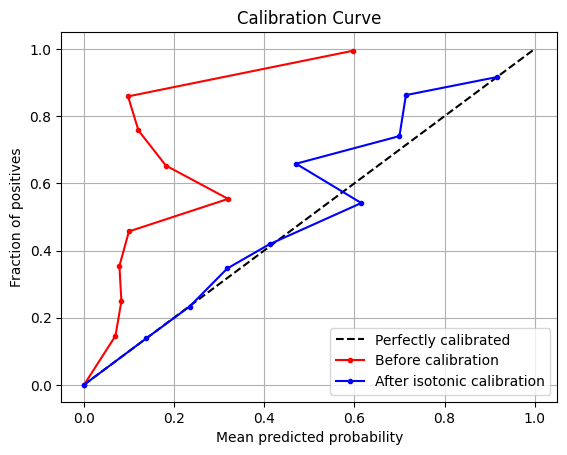

In [7]:

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Plot
plt.figure()
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(*calibration_curve(y_test, y_prob, n_bins=10), 'r.-', label='Before calibration')
plt.plot(*calibration_curve(y_test, y_calibrated_prob, n_bins=10), 'b.-', label='After isotonic calibration')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

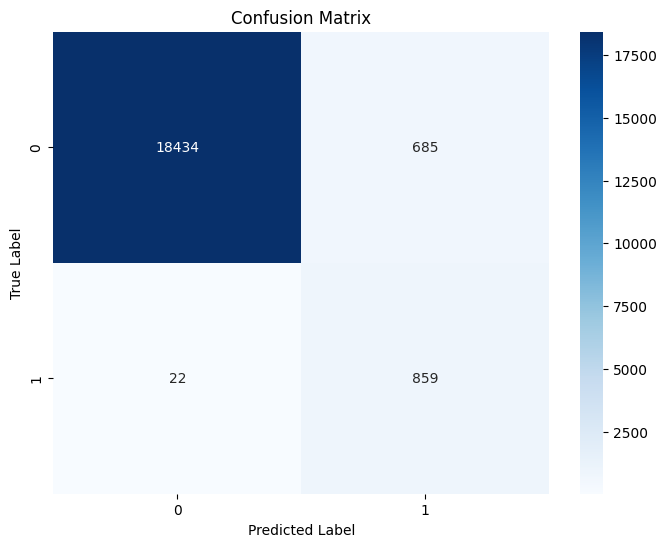

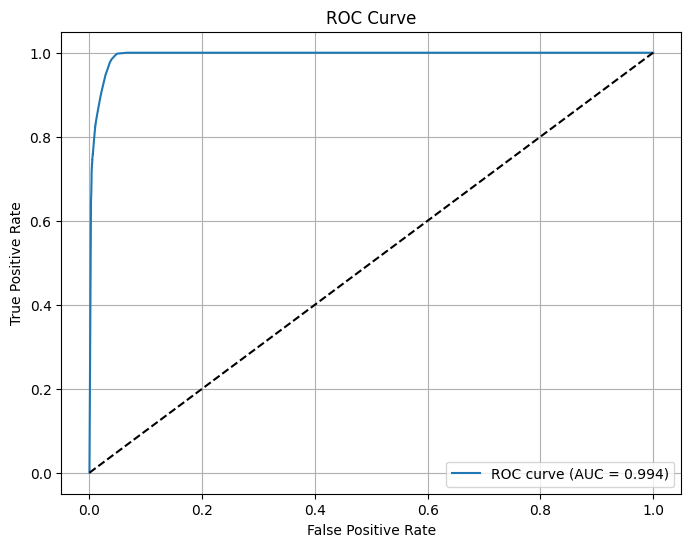

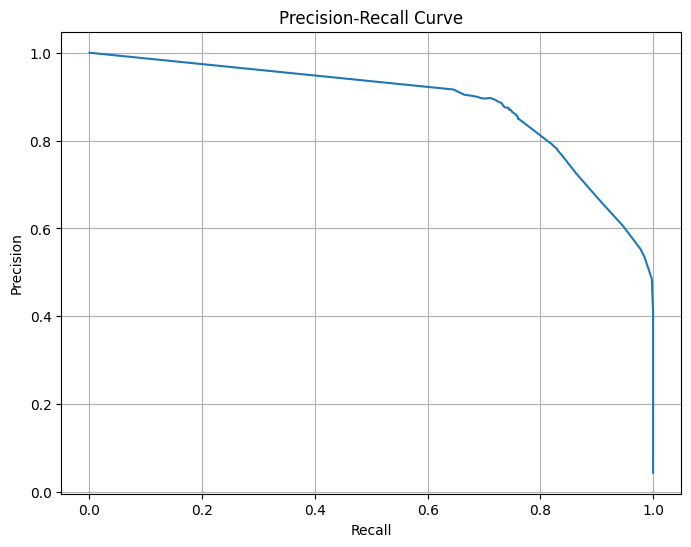

In [9]:
# Additional model evaluation steps:

# 1. Feature importance analysis
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(importances)), importances)
    plt.title('Feature Importances')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

# 2. Confusion Matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_calibrated_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_calibrated_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()